# TRABAJO SUMATIVO — UNIDAD 3
## Machine Learning

---

#### Carrera:
Ingeniería Civil Industrial  

#### Asignatura:
Machine Learning  

#### Profesor:
Franco Andrés Mansilla  

#### Fecha de entrega:
4 de abril de 2026  

---

### Integrantes
- Diego Miranda  
- Arturo Irribarra  
- Ignacio Gutiérrez  
- Sebastián Martínez  
- Cristian Vergara  

---

## Caso de estudio
**Walmart Sales Forecasting**

---

## Descripción general

En el presente trabajo se aborda un problema de aprendizaje no supervisado aplicado al caso Walmart Sales Forecasting, utilizando información histórica de ventas, variables económicas, características de las tiendas y datos asociados a promociones.

A diferencia de los trabajos anteriores (TS1 y TS2), en los cuales se desarrollaron modelos supervisados para predicción y clasificación de ventas, en esta etapa el enfoque se centra en la exploración de estructuras latentes en los datos, sin utilizar variables objetivo.

El objetivo principal es identificar patrones y segmentaciones naturales dentro del dataset mediante el uso de técnicas de clustering, tales como K-Means y DBSCAN, junto con herramientas de reducción de dimensionalidad como el Análisis de Componentes Principales (PCA).

Adicionalmente, se evaluarán los resultados utilizando métricas de clustering como Silhouette Score y Davies-Bouldin Index, con el fin de analizar la calidad de los grupos obtenidos.



---

## Metodología

El notebook se estructura en las siguientes etapas:

1. Integración y preparación de datos.
2. Escalado de variables numéricas.
3. Reducción de dimensionalidad mediante PCA.
4. Aplicación de algoritmos de clustering.
5. Evaluación mediante métricas de clustering.
6. Visualización e interpretación de resultados.

---

### BLOQUE 1 — CARGA Y PREPARACIÓN DE DATOS TS3

Se aplica PCA para reducir la dimensionalidad del dataset, conservando aproximadamente el 90% de la varianza total y facilitando el procesamiento de los algoritmos de clustering.

In [ ]:
import pandas as pd
from google.colab import files

print("Cargando datasets para preparación de datos...")

train = pd.read_csv("train.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

# Merge de datasets
df = train.merge(features, on=["Store", "Date"], how="left")
df = df.merge(stores, on="Store", how="left")

print("Dataset combinado:", df.shape)

# Limpieza básica

# Convertir fecha
df["Date"] = pd.to_datetime(df["Date"])

# Variables temporales
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

# Tratamiento de NaN (MarkDowns)
markdown_cols = ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]

for col in markdown_cols:
    df[col] = df[col].fillna(0)

# Variables binarias (presencia de markdown)
for col in markdown_cols:
    df[f"{col}_bin"] = (df[col] > 0).astype(int)

# Variable agregada
df["Has_MarkDown"] = (df[markdown_cols].sum(axis=1) > 0).astype(int)

# Selección final para clustering

cols_to_drop = [
    "Date",
    "Weekly_Sales"
]

df_ts3 = df.drop(columns=cols_to_drop, errors="ignore")

# Eliminar IDs
df_ts3 = df_ts3.drop(columns=["Store", "Dept"], errors="ignore")

# Solo variables numéricas
df_ts3 = df_ts3.select_dtypes(include=["int64", "float64", "int32", "float32"])

# Guardar dataset
# Para evitar alto costo computacional en clustering,
# se utiliza una muestra representativa del dataset.

sample_size = 100000

if len(df_ts3) > sample_size:
    df_ts3 = df_ts3.sample(
        n=sample_size,
        random_state=42
    )

# Resetear índices
df_ts3 = df_ts3.reset_index(drop=True)

print("Dataset final TS3:", df_ts3.shape)


# Guardar dataset final

df_ts3.to_csv("dataset_ts3_final.csv", index=False)

df_ts3.head()


📂 Cargando datasets para preparación de datos...
Dataset combinado: (421570, 17)
Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'Type', 'Size',
       'Year', 'Month', 'Week', 'MarkDown1_bin', 'MarkDown2_bin',
       'MarkDown3_bin', 'MarkDown4_bin', 'MarkDown5_bin', 'Has_MarkDown'],
      dtype='object')
Dataset final TS3: (100000, 19)


,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Year,Month,Week,MarkDown1_bin,MarkDown2_bin,MarkDown3_bin,MarkDown4_bin,MarkDown5_bin,Has_MarkDown
0,50.43,3.599,5155.86,19549.51,218.29,636.73,5218.50,130.157516,12.187,206302,2012,1,1,1,1,1,1,1,1
1,38.10,3.876,7410.18,368.19,25.46,1852.39,2332.07,137.506690,8.075,120653,2012,3,10,1,1,1,1,1,1
2,76.67,4.087,0.00,0.00,0.00,0.00,0.00,129.062355,13.736,39690,2011,5,21,0,0,0,0,0,0
3,43.43,2.805,0.00,0.00,0.00,0.00,0.00,131.784000,10.064,93638,2010,3,10,0,0,0,0,0,0
4,45.12,2.841,0.00,0.00,0.00,0.00,0.00,126.436419,7.795,219622,2010,10,43,0,0,0,0,0,0


### BLOQUE 2 — CARGA DEL DATASET FINAL

In [ ]:
df_ts3 = pd.read_csv("dataset_ts3_final.csv")
df_ts3.head()

,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Year,Month,Week,MarkDown1_bin,MarkDown2_bin,MarkDown3_bin,MarkDown4_bin,MarkDown5_bin,Has_MarkDown
0,50.43,3.599,5155.86,19549.51,218.29,636.73,5218.50,130.157516,12.187,206302,2012,1,1,1,1,1,1,1,1
1,38.10,3.876,7410.18,368.19,25.46,1852.39,2332.07,137.506690,8.075,120653,2012,3,10,1,1,1,1,1,1
2,76.67,4.087,0.00,0.00,0.00,0.00,0.00,129.062355,13.736,39690,2011,5,21,0,0,0,0,0,0
3,43.43,2.805,0.00,0.00,0.00,0.00,0.00,131.784000,10.064,93638,2010,3,10,0,0,0,0,0,0
4,45.12,2.841,0.00,0.00,0.00,0.00,0.00,126.436419,7.795,219622,2010,10,43,0,0,0,0,0,0


El dataset final generado en la etapa anterior es utilizado como base para el análisis de clustering, permitiendo separar claramente la preparación de datos del modelamiento.

### BLOQUE 3 — ESCALADO DE VARIABLES

Dado que los algoritmos de clustering se basan en medidas de distancia, es necesario normalizar las variables para evitar que aquellas con mayor escala dominen el análisis.

Se utiliza StandardScaler para centrar los datos y ajustar su varianza.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ts3)

print("Escalado completado")
print("Dimensiones:", X_scaled.shape)

Escalado completado
Dimensiones: (100000, 19)


### BLOQUE 4 — Análisis de Componentes Principales (PCA)

Se aplica PCA con el objetivo de reducir la dimensionalidad del dataset, manteniendo la mayor cantidad de información posible.

A partir del análisis de la varianza explicada acumulada, se selecciona el número de componentes necesarios para conservar aproximadamente el 90% de la varianza total.

Esto permite simplificar la estructura de los datos, reducir el ruido y mejorar el desempeño de los algoritmos de clustering, facilitando además la visualización en un espacio de menor dimensión.

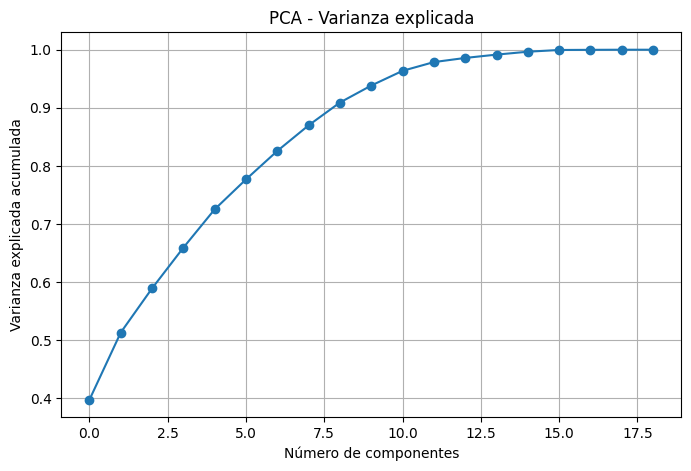

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# varianza explicada acumulada
var_acum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(var_acum, marker='o')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA - Varianza explicada")
plt.grid()
plt.show()

In [ ]:
# seleccionar componentes que expliquen 90% de varianza
n_components = np.argmax(var_acum >= 0.90) + 1

print("Componentes seleccionados:", n_components)

pca_final = PCA(n_components=n_components)
X_pca_final = pca_final.fit_transform(X_scaled)

Componentes seleccionados: 9


### BLOQUE 5 — Benchmarking con y sin PCA

En esta etapa se comparan distintos algoritmos de clustering utilizando métricas como Silhouette Score, Davies-Bouldin y Calinski-Harabasz.

La evaluación se realiza utilizando tanto la base original escalada como la versión reducida mediante PCA.

In [ ]:
import numpy as np
import pandas as pd
import gc

from sklearn.cluster import MiniBatchKMeans, Birch, AgglomerativeClustering, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Muestra pequeña para evitar colapso de memoria
sample_size = 10000
np.random.seed(42)

idx_benchmark = np.random.choice(
    X_scaled.shape[0],
    size=min(sample_size, X_scaled.shape[0]),
    replace=False
)

X_scaled_benchmark = X_scaled[idx_benchmark]
X_pca_benchmark = X_pca_final[idx_benchmark]

def evaluar(nombre, tipo, base, X_data, labels):
    labels = np.array(labels)

    valid_mask = labels != -1
    X_valid = X_data[valid_mask]
    labels_valid = labels[valid_mask]

    n_clusters = len(set(labels_valid))
    ruido = int(np.sum(labels == -1))

    if n_clusters < 2:
        return {
            "Modelo": nombre,
            "Tipo": tipo,
            "Base": base,
            "Clusters": n_clusters,
            "Ruido": ruido,
            "Silhouette": None,
            "Davies-Bouldin": None,
            "Calinski-Harabasz": None
        }

    return {
        "Modelo": nombre,
        "Tipo": tipo,
        "Base": base,
        "Clusters": n_clusters,
        "Ruido": ruido,
        "Silhouette": silhouette_score(X_valid, labels_valid),
        "Davies-Bouldin": davies_bouldin_score(X_valid, labels_valid),
        "Calinski-Harabasz": calinski_harabasz_score(X_valid, labels_valid)
    }

def modelos():
    return [
        ("MiniBatchKMeans", "Distancia", MiniBatchKMeans(n_clusters=3, random_state=42, batch_size=512, n_init=10)),
        ("BIRCH", "Distancia", Birch(n_clusters=3)),
        ("Agglomerative", "Distancia", AgglomerativeClustering(n_clusters=3)),
        ("DBSCAN", "Densidad", DBSCAN(eps=1.5, min_samples=10, n_jobs=-1)),
        ("OPTICS", "Densidad", OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05, n_jobs=-1))
    ]

resultados = []

for base_nombre, X_base in [("Con PCA", X_pca_benchmark), ("Sin PCA", X_scaled_benchmark)]:
    for nombre, tipo, modelo in modelos():
        print(f"Ejecutando {nombre} - {base_nombre}...")

        try:
            labels = modelo.fit_predict(X_base)
            resultados.append(evaluar(nombre, tipo, base_nombre, X_base, labels))

        except Exception as e:
            resultados.append({
                "Modelo": nombre,
                "Tipo": tipo,
                "Base": base_nombre,
                "Clusters": None,
                "Ruido": None,
                "Silhouette": None,
                "Davies-Bouldin": None,
                "Calinski-Harabasz": None,
                "Error": str(e)
            })

        del modelo
        gc.collect()

benchmark_df = pd.DataFrame(resultados)
benchmark_df

Ejecutando MiniBatchKMeans - Con PCA...
Ejecutando BIRCH - Con PCA...
Ejecutando Agglomerative - Con PCA...
Ejecutando DBSCAN - Con PCA...
Ejecutando OPTICS - Con PCA...
Ejecutando MiniBatchKMeans - Sin PCA...
Ejecutando BIRCH - Sin PCA...
Ejecutando Agglomerative - Sin PCA...
Ejecutando DBSCAN - Sin PCA...
Ejecutando OPTICS - Sin PCA...


,Modelo,Tipo,Base,Clusters,Ruido,Silhouette,Davies-Bouldin,Calinski-Harabasz
3,DBSCAN,Densidad,Con PCA,4,395,0.446929,0.726758,3048.412781
1,BIRCH,Distancia,Con PCA,3,0,0.445963,0.895744,4298.773078
2,Agglomerative,Distancia,Con PCA,3,0,0.445963,0.895744,4298.773078
6,BIRCH,Distancia,Sin PCA,3,0,0.415406,0.986974,3651.064595
9,OPTICS,Densidad,Sin PCA,5,6804,0.318754,1.336742,1450.250965


### BLOQUE 6 — Modelo seleccionado

MiniBatchKMeans fue seleccionado como modelo principal debido a su estabilidad, escalabilidad y eficiencia computacional para trabajar con grandes volúmenes de datos.

In [ ]:
from sklearn.cluster import MiniBatchKMeans

kmeans_final = MiniBatchKMeans(
    n_clusters=3,
    random_state=42,
    batch_size=2048,
    n_init=10
)

labels_kmeans = kmeans_final.fit_predict(X_pca_final)

df_ts3["cluster"] = labels_kmeans

df_ts3.groupby("cluster").mean()

,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Year,Month,Week,MarkDown1_bin,MarkDown2_bin,MarkDown3_bin,MarkDown4_bin,MarkDown5_bin,Has_MarkDown
cluster,,,,,,,,,,,,,,,,,,,
0,51.165643,3.240620,0.000000,0.000000,0.000000,0.000000,0.339545,165.592645,8.366711,136639.476320,2010.565649,3.523234,12.958615,0.000000,0.000000,0.000000,0.000000,0.000481,0.000481
1,59.927159,3.659612,7281.537002,2477.115903,1356.223272,3058.478326,4620.082000,174.750636,7.393640,136631.793790,2011.844233,6.469243,26.151133,0.998280,0.727477,0.904997,0.895896,1.000000,1.000000
2,67.695458,3.159310,0.413044,0.000000,0.015643,0.000000,2.904447,172.178660,8.161127,136870.628523,2010.412232,8.864704,36.214511,0.001521,0.000000,0.001464,0.000000,0.004276,0.004276


### BLOQUE 7 — VISUALIZACIÓN

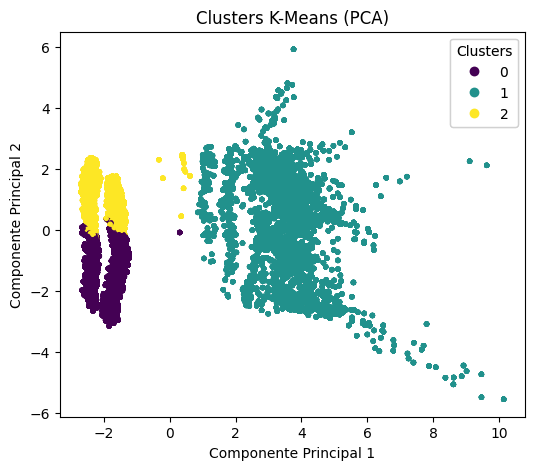

In [ ]:
plt.figure(figsize=(6,5))

scatter = plt.scatter(
    X_pca_final[:,0],
    X_pca_final[:,1],
    c=labels_kmeans,
    cmap='viridis',
    s=8
)

legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)

plt.title("Clusters K-Means (PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

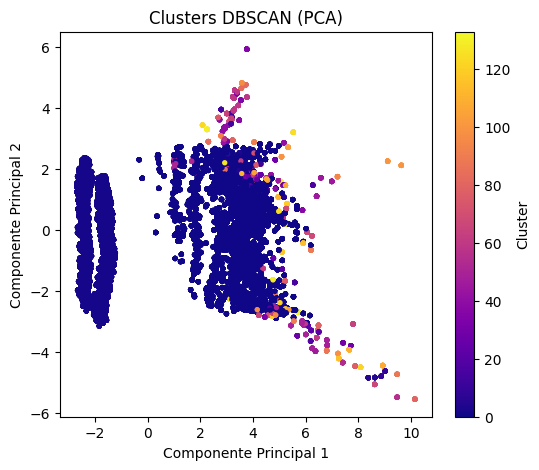

In [ ]:
from sklearn.cluster import DBSCAN

# aplicar DBSCAN sobre PCA
dbscan_final = DBSCAN(
    eps=1.5,
    min_samples=10,
    n_jobs=-1
)

labels_dbscan = dbscan_final.fit_predict(X_pca_final)

plt.figure(figsize=(6,5))

scatter = plt.scatter(
    X_pca_final[:,0],
    X_pca_final[:,1],
    c=labels_dbscan,
    cmap='plasma',
    s=8
)

plt.colorbar(scatter, label="Cluster")

plt.title("Clusters DBSCAN (PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

En DBSCAN, el valor -1 representa observaciones consideradas como ruido o anomalías.

A diferencia de K-Means, DBSCAN permite detectar estructuras complejas sin definir previamente el número de clusters.



## Comparación final de modelos

La siguiente tabla resume los principales resultados obtenidos durante el benchmarking de algoritmos de clustering.

In [ ]:
benchmark_df_sorted = benchmark_df.sort_values(
    by=["Silhouette", "Davies-Bouldin"],
    ascending=[False, True],
    na_position="last"
)

benchmark_df_sorted

,Modelo,Tipo,Base,Clusters,Ruido,Silhouette,Davies-Bouldin,Calinski-Harabasz
3,DBSCAN,Densidad,Con PCA,4,395,0.446929,0.726758,3048.412781
1,BIRCH,Distancia,Con PCA,3,0,0.445963,0.895744,4298.773078
2,Agglomerative,Distancia,Con PCA,3,0,0.445963,0.895744,4298.773078
6,BIRCH,Distancia,Sin PCA,3,0,0.415406,0.986974,3651.064595
9,OPTICS,Densidad,Sin PCA,5,6804,0.318754,1.336742,1450.250965
0,MiniBatchKMeans,Distancia,Con PCA,3,0,0.309300,1.686723,4044.015483
4,OPTICS,Densidad,Con PCA,5,6849,0.214198,1.866642,585.634758
7,Agglomerative,Distancia,Sin PCA,3,0,0.203950,1.560351,3665.089083
5,MiniBatchKMeans,Distancia,Sin PCA,3,0,0.195682,1.842143,3585.257317
8,DBSCAN,Densidad,Sin PCA,31,915,0.166634,1.091867,410.809318


A partir del benchmarking realizado, se selecciona MiniBatchKMeans como modelo principal para el análisis final.

Si bien algoritmos como BIRCH y Agglomerative presentaron métricas ligeramente superiores en algunos indicadores, MiniBatchKMeans fue seleccionado debido a su mayor eficiencia computacional, estabilidad y escalabilidad frente a grandes volúmenes de datos.

Además, K-Means permite una interpretación visual más clara de los clusters obtenidos, facilitando el análisis exploratorio del dataset.

### Conclusión

Las técnicas de clustering permitieron identificar patrones y segmentaciones relevantes dentro del dataset Walmart Sales Forecasting.

El uso de PCA facilitó la reducción de dimensionalidad y mejoró el desempeño de algunos algoritmos evaluados.

Finalmente, MiniBatchKMeans fue seleccionado como modelo principal debido a su estabilidad y eficiencia computacional.